# Heston Historical Calibration — Production Pipeline

This notebook implements a production-oriented historical calibration of the Heston
stochastic volatility model using the A2 pipeline (daily returns + realized variance).

## Design philosophy

Some Heston parameters are **structurally unidentifiable** from historical returns +
realized variance alone:

| Parameter | Identifiability from returns+RV | Default treatment |
|---|---|---|
| **κ** (mean-reversion speed) | Good (via RV autocorrelation) | Calibrate |
| **θ** (long-run variance) | Good (via mean RV) | Calibrate |
| **ρ** (leverage) | Good (via return–RV correlation) | Calibrate |
| **σ** (vol-of-vol) | Weak — requires many years or options data | Calibrate or fix |
| **v₀** (initial variance) | Very weak — process forgets it quickly | Fix to early RV |

**v₀** is anchored to the early realized variance by default. This is principled:
the mean-reversion erases memory of v₀ on a timescale of 1/κ days, so the data
after the first few weeks contains almost no information about v₀. Fixing it removes
one poorly-identified dimension from the posterior.

**σ** can be calibrated (wider posterior, requires user interpretation) or fixed
to a value from an external source (options calibration, literature).

## How to use

1. Edit the **CONFIG cell** immediately below — set fixed parameter values and NUTS settings
2. Replace the data loading section with your real data (or leave synthetic for testing)
3. Run all cells
4. Use the diagnostics section to assess fit quality — these work even without ground truth

In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# USER CONFIGURATION — this is the only cell you need to edit for a new dataset
# ═══════════════════════════════════════════════════════════════════════════════

# Parameters to FIX (not sampled by NUTS).
#   "auto"  — estimated from data (v0 only: mean of first N_V0_DAYS of RV/dt)
#   float   — exact fixed value
#   None    — calibrate (include in NUTS posterior)
FIXED = {
    "v0":    "auto",  # anchored to early realized variance
    "sigma": None,    # set e.g. 0.4 to fix; None to calibrate
}
N_V0_DAYS = 5         # days of early RV to average for auto v0

# Prior specification for FREE parameters.
# Each entry is (mean, std) for the *unconstrained* parameterisation:
#   log_kappa, log_theta, log_sigma, rho_raw = arctanh(rho), log_v0
# Ignored for fixed parameters.
PRIORS = {
    "kappa": (0.5,  2.0),
    "theta": (-3.2, 1.5),
    "sigma": (-0.5, 1.5),
    "rho":   (0.0,  1.5),
    "v0":    (-3.2, 1.5),
}

# Feller condition soft penalty
# The Feller condition 2κθ > σ² ensures variance stays positive.
# When violated the penalty adds  -FELLER_STRENGTH * (σ² - 2κθ)  to the
# log-posterior (zero when satisfied, linearly penalises the violation).
# Scale intuition: a violation of 0.1 costs STRENGTH * 0.1 nats.
# With a total log-lik of ~2770 over 252 days, a strength of 50 makes a
# violation of 0.1 cost ~5 nats — noticeable but not a cliff.
# Set to 0.0 to disable (useful to see the unconstrained posterior first).
FELLER_STRENGTH = 50.0

# NUTS sampler settings
NUTS_CFG = {
    "num_warmup":         800,
    "num_samples":        1500,
    "num_chains":         4,
    "target_accept_prob": 0.9,
    "dense_mass":         True,   # learns off-diagonal correlations; needs ≥800 warmup
}

# ── Data settings ─────────────────────────────────────────────────────────────
# Set USE_SYNTHETIC = False and replace the data loading block in the Data cell
# with your actual return and RV series.
USE_SYNTHETIC = True
SYNTHETIC_SEED = 0
H_PER_DAY = 8    # intraday bars per day used to compute daily RV
                 # higher H → tighter RV proxy → better σ identifiability

# ── Ground-truth parameters (synthetic only — ignored on real data) ────────────
# Set all to None when running on real data.
TRUE_PARAMS = {
    "kappa": 3.0,
    "theta": 0.04,
    "sigma": 0.4,
    "rho":   -0.7,
    "v0":    0.04,
}

print("Configuration loaded.")
free_params  = [p for p, v in FIXED.items() if v is None]
fixed_params = [p for p, v in FIXED.items() if v is not None]
always_free  = [p for p in ["kappa", "theta", "sigma", "rho", "v0"]
                if p not in FIXED]
calibrated   = always_free + free_params   # all params that NUTS will sample
print(f"  Calibrated    : {calibrated}")
print(f"  Fixed         : {fixed_params}  (values resolved after data load)")
print(f"  Feller penalty: {FELLER_STRENGTH}  ({'active' if FELLER_STRENGTH > 0 else 'disabled'})")

Configuration loaded.
  Calibrated    : ['kappa', 'theta', 'rho', 'sigma']
  Fixed         : ['v0']  (values resolved after data load)
  Feller penalty: 50.0  (active)


In [2]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"   # Metal GPU lacks popcnt used by NUTS

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import corner
import arviz as az
import scipy.optimize as opt
import scipy.stats as stats
import time

import jax
jax.config.update("jax_enable_x64", True)   # MUST be before any jnp usage
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, init_to_value

np.random.seed(42)
MU = 0.05   # drift — known, not calibrated
print(f"JAX {jax.__version__}  NumPyro {numpyro.__version__}")
print(f"Devices: {jax.devices()}")
print(f"Default dtype: {jnp.zeros(1).dtype}  (must be float64)")

Platform 'METAL' is experimental and not all JAX functionality may be correctly supported!


JAX 0.4.35  NumPyro 0.19.0
Metal device set to: Apple M3 Pro

systemMemory: 36.00 GB
maxCacheSize: 14.04 GB

Devices: [CpuDevice(id=0)]
Default dtype: float64  (must be float64)


W0000 00:00:1776535288.640585 32427324 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1776535288.653313 32427324 service.cc:145] XLA service 0x14f710a90 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776535288.653321 32427324 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1776535288.654540 32427324 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1776535288.654548 32427324 mps_client.cc:384] XLA backend will use up to 30150197248 bytes on device 0 for SimpleAllocator.


## Data

For production use, replace the block inside `if not USE_SYNTHETIC` with code that loads:
- `r_daily`  — array of shape `(T,)` containing daily log-returns
- `RV_daily` — array of shape `(T,)` containing daily realized variance
  (= sum of squared intraday log-returns over `H_PER_DAY` bars)

Both should be in **annualized** units consistent with `dt = 1/252`.
RV should be the **sum** of squared intraday returns (not the mean), so that
`E[RV_t] ≈ v_t · dt` matches the UKF observation model.

In [3]:
T  = 252
dt = 1 / 252

if USE_SYNTHETIC:
    # ── Synthetic Heston simulation ────────────────────────────────────────────
    def simulate_heston(kappa, theta, sigma, rho, v0, mu=MU, S0=100.0,
                        T=T, dt=dt, seed=None):
        rng = np.random.default_rng(seed)
        v, S = np.zeros(T + 1), np.zeros(T + 1)
        v[0], S[0] = v0, S0
        z1, z2 = rng.standard_normal(T), rng.standard_normal(T)
        dWs = np.sqrt(dt) * z1
        dWv = np.sqrt(dt) * (rho * z1 + np.sqrt(1 - rho**2) * z2)
        for t in range(T):
            sv     = np.sqrt(max(v[t], 0.0))
            v[t+1] = max(v[t] + kappa*(theta - v[t])*dt + sigma*sv*dWv[t], 0.0)
            S[t+1] = S[t] * np.exp((mu - 0.5*v[t])*dt + sv*dWs[t])
        return S, v, np.log(S[1:] / S[:-1])

    T_hourly  = T * H_PER_DAY
    dt_hourly = 1.0 / (252 * H_PER_DAY)
    S_h, v_h, r_h = simulate_heston(**TRUE_PARAMS, T=T_hourly, dt=dt_hourly,
                                     seed=SYNTHETIC_SEED)
    r_daily  = r_h.reshape(T, H_PER_DAY).sum(axis=1)
    RV_daily = (r_h ** 2).reshape(T, H_PER_DAY).sum(axis=1)
    v_true   = v_h[H_PER_DAY::H_PER_DAY]   # end-of-day true variance (for diagnostics)

else:
    # ── REAL DATA — replace this block ────────────────────────────────────────
    # r_daily  = np.load("path/to/daily_log_returns.npy")      # shape (T,)
    # RV_daily = np.load("path/to/daily_realized_variance.npy") # shape (T,)
    # T = len(r_daily)
    # v_true = None   # no ground truth on real data
    raise NotImplementedError("Load your real data here and set v_true = None")

rdaily_jax = jnp.array(r_daily)
rv_jax     = jnp.array(RV_daily)

rv_v_corr = (np.corrcoef(RV_daily / dt, v_true)[0, 1]
             if v_true is not None else float('nan'))

print(f"T = {T} daily observations")
print(f"Mean return (ann.):  {r_daily.mean()*252:.3f}")
print(f"Mean RV/dt:          {(RV_daily/dt).mean():.4f}  "
      f"(proxy for θ; true θ = {TRUE_PARAMS['theta'] if USE_SYNTHETIC else 'unknown':.4f})")
print(f"RV–v corr:           {rv_v_corr:.3f}  (1.0 = perfect proxy; H={H_PER_DAY} bars)")

T = 252 daily observations
Mean return (ann.):  -0.208
Mean RV/dt:          0.0416  (proxy for θ; true θ = 0.0400)
RV–v corr:           0.752  (1.0 = perfect proxy; H=8 bars)


## Resolving fixed parameter values

**v₀ = "auto"** is resolved here from the data. This happens after the data
is loaded so the estimate uses the actual observed RV series.

Any manually-specified fixed values are validated for plausibility.

In [4]:
# ── Resolve "auto" and user-supplied fixed values ──────────────────────────────

resolved_fixed = {}

for param, spec in FIXED.items():
    if spec is None:
        continue   # free — NUTS will sample it
    elif spec == "auto":
        if param == "v0":
            val = float(np.mean(RV_daily[:N_V0_DAYS]) / dt)
            val = float(np.clip(val, 1e-4, 1.0))   # sanity bounds
        else:
            raise ValueError(f"'auto' is only supported for v0, not {param}")
        resolved_fixed[param] = val
    else:
        resolved_fixed[param] = float(spec)

# Full parameter dict used for UKF evaluation (free params filled in later)
# For display purposes only:
print("Fixed parameter values (resolved):")
for p, v in resolved_fixed.items():
    true_str = f"  (true: {TRUE_PARAMS[p]:.4f})" if (USE_SYNTHETIC and TRUE_PARAMS) else ""
    print(f"  {p:<8} = {v:.4f}{true_str}")

print(f"\nFree parameters (will be calibrated): {calibrated}")

# Plausibility warnings
if "sigma" in resolved_fixed:
    s = resolved_fixed["sigma"]
    kth = resolved_fixed.get("kappa", 3.0) * resolved_fixed.get("theta", 0.04)
    if s**2 / 2 >= kth:
        print(f"\nWARNING: Feller condition 2κθ > σ² may be violated with σ={s:.3f}.")
        print("         Variance can hit zero; consider increasing σ or fixing κ/θ.")

if "v0" in resolved_fixed:
    v = resolved_fixed["v0"]
    if v < 0.0001 or v > 1.0:
        print(f"WARNING: v0={v:.4f} is outside plausible range [0.0001, 1.0].")

Fixed parameter values (resolved):
  v0       = 0.0294  (true: 0.0400)

Free parameters (will be calibrated): ['kappa', 'theta', 'rho', 'sigma']


## 2D Unscented Kalman Filter

State: `v_t` (scalar variance).  Observations per day: `[r_t, RV_t]`.

The UKF always receives all 5 Heston parameters — fixed and free alike.
Fixed parameters are constants; free parameters are JAX-traced variables
so that NUTS can differentiate through the filter.

**Floor note**: `S_rvrv ≈ P·dt² + 2v²·dt²/H ≈ 8×10⁻⁹` with typical values.
Floors are set to `1e-12` so they never fire in normal operation.

In [5]:
def ukf_rv_loglik_jax(daily_returns, daily_rv, kappa, theta, sigma, rho, v0,
                       mu=MU, dt=1/252, n_intraday=H_PER_DAY):
    """2D JAX UKF log-likelihood. Differentiable via jax.grad."""
    W0, Wi = 2.0/3.0, 1.0/6.0

    def step(carry, obs_t):
        m, P = carry
        r_t, rv_t = obs_t[0], obs_t[1]
        v_s = jnp.maximum(m, 1e-6)

        sp  = jnp.sqrt(3.0 * P)
        f0  = m        + kappa*(theta - m       )*dt
        f1  = (m + sp) + kappa*(theta - (m + sp))*dt
        f2  = (m - sp) + kappa*(theta - (m - sp))*dt
        m_p = W0*f0 + Wi*(f1 + f2)
        P_p = jnp.maximum(
            W0*(f0-m_p)**2 + Wi*((f1-m_p)**2 + (f2-m_p)**2) + sigma**2*v_s*dt,
            1e-8)
        v_p = jnp.maximum(m_p, 1e-6)

        yr_p  = (mu - 0.5*m_p)*dt
        yrv_p = m_p * dt

        S_rr   = jnp.maximum(0.25*P_p*dt**2 + v_p*dt,                   1e-12)
        S_rvrv = jnp.maximum(P_p*dt**2 + 2.0*v_p**2*dt**2/n_intraday,  1e-12)
        S_r_rv = -0.5*P_p*dt**2

        Pvy_r  = -0.5*P_p*dt + rho*sigma*v_p*dt
        Pvy_rv = P_p*dt

        det    = jnp.maximum(S_rr*S_rvrv - S_r_rv**2, 1e-14)
        K_r    = (Pvy_r*S_rvrv  - Pvy_rv*S_r_rv) / det
        K_rv   = (Pvy_rv*S_rr   - Pvy_r*S_r_rv ) / det

        innov_r  = r_t  - yr_p
        innov_rv = rv_t - yrv_p
        m_new = jnp.maximum(m_p + K_r*innov_r + K_rv*innov_rv, 1e-6)
        P_new = jnp.maximum(P_p - K_r*Pvy_r   - K_rv*Pvy_rv,  1e-8)

        # Mahalanobis terms for log-lik
        si_r  = (S_rvrv*innov_r  - S_r_rv*innov_rv) / det
        si_rv = (S_rr  *innov_rv - S_r_rv*innov_r ) / det
        ll    = -0.5*(2.0*jnp.log(2.0*jnp.pi) + jnp.log(det)
                     + innov_r*si_r + innov_rv*si_rv)

        return (m_new, P_new), (ll, m_new, innov_r / jnp.sqrt(S_rr),
                                           innov_rv / jnp.sqrt(S_rvrv))

    obs_arr = jnp.stack([daily_returns, daily_rv], axis=1)
    init    = (jnp.maximum(v0, 1e-6), jnp.maximum(theta*0.5, 1e-8))
    _, (lls, filtered_v, innov_r_std, innov_rv_std) = jax.lax.scan(step, init, obs_arr)
    return jnp.sum(lls), filtered_v, innov_r_std, innov_rv_std


def ukf_loglik_only(daily_returns, daily_rv, kappa, theta, sigma, rho, v0):
    """Scalar log-lik only — for use as NUTS factor and MAP objective."""
    ll, _, _, _ = ukf_rv_loglik_jax(daily_returns, daily_rv, kappa, theta, sigma, rho, v0)
    return ll


# Sanity check at true params (synthetic) or mean-RV guess (real)
test_params = TRUE_PARAMS.copy() if USE_SYNTHETIC else {
    "kappa": 2.0, "theta": float(np.mean(RV_daily)/dt),
    "sigma": 0.4, "rho": -0.5, "v0": resolved_fixed.get("v0", float(np.mean(RV_daily[:5])/dt))
}
# Override with any fixed values
test_params.update(resolved_fixed)

ll_test, fv_test, ir_test, irv_test = ukf_rv_loglik_jax(
    rdaily_jax, rv_jax, **{k: float(v) for k, v in test_params.items()})
print(f"UKF log-lik at test params: {float(ll_test):.2f}")
print("UKF compiled successfully.")

UKF log-lik at test params: 2769.13
UKF compiled successfully.


## MAP Optimisation (warm-start)

L-BFGS-B on the MAP objective (log-likelihood + log-prior) using JAX analytical
gradients. Only the **free** parameters are optimised; fixed parameters enter as
constants.

The MAP estimate initialises the NUTS chains at the posterior mode, so warmup
only needs to calibrate the step-size rather than locate the mode.

In [6]:
# ── Helpers: constrained ↔ unconstrained ──────────────────────────────────────

ALL_PARAMS = ["kappa", "theta", "sigma", "rho", "v0"]

def to_unc(p, val):
    """Transform one constrained param to unconstrained space."""
    if p == "rho":   return float(np.arctanh(np.clip(val, -0.999, 0.999)))
    else:            return float(np.log(val))

def from_unc(p, u):
    """Transform one unconstrained value back to constrained space."""
    if p == "rho":   return float(jnp.tanh(u))
    else:            return float(jnp.exp(u))


def feller_penalty(kappa, theta, sigma):
    """Soft Feller penalty — zero when 2κθ ≥ σ², linearly penalises violations.
    Returns a log-space penalty (negative when violated, zero otherwise)."""
    violation = jnp.maximum(sigma**2 - 2.0 * kappa * theta, 0.0)
    return -FELLER_STRENGTH * violation


# ── Starting point: moment estimators ────────────────────────────────────────

def moment_init():
    """Rough moment estimators — just needs to be in the right basin."""
    theta0 = float(np.mean(RV_daily) / dt)
    v0_0   = resolved_fixed.get("v0", float(np.mean(RV_daily[:N_V0_DAYS]) / dt))
    phi    = np.corrcoef(RV_daily[:-1], RV_daily[1:])[0, 1]
    phi    = np.clip(phi, 0.01, 0.999)
    kappa0 = float(np.clip(-np.log(phi) / dt, 0.1, 30.0))
    dRV    = np.diff(RV_daily)
    sigma0 = float(np.clip(np.sqrt(np.var(dRV) / (theta0 * dt**2)), 0.05, 5.0))
    rho0   = float(np.clip(np.corrcoef(r_daily[1:], dRV)[0, 1], -0.99, 0.99))
    return {"kappa": kappa0, "theta": theta0, "sigma": sigma0, "rho": rho0, "v0": v0_0}

moment_guess = moment_init()


# ── Build MAP objective over FREE params only ─────────────────────────────────

def make_full_params_jax(psi_free):
    """Given free-param vector in unconstrained space, return all 5 Heston params."""
    out = {}
    idx = 0
    for p in ALL_PARAMS:
        if p in resolved_fixed:
            out[p] = jnp.array(resolved_fixed[p])
        else:
            u = psi_free[idx]
            out[p] = jnp.tanh(u) if p == "rho" else jnp.exp(u)
            idx += 1
    return out


def map_objective(psi_free):
    """MAP = log-lik + log-prior + Feller penalty over free parameters."""
    params = make_full_params_jax(psi_free)
    ll = ukf_loglik_only(rdaily_jax, rv_jax, **params)
    # Log-prior (only for free params)
    lp = jnp.array(0.0)
    idx = 0
    for p in ALL_PARAMS:
        if p not in resolved_fixed:
            mu_pr, sd_pr = PRIORS[p]
            lp = lp - 0.5 * ((psi_free[idx] - mu_pr) / sd_pr)**2
            idx += 1
    # Feller soft penalty — only meaningful when σ is free
    fp = feller_penalty(params["kappa"], params["theta"], params["sigma"])
    return ll + lp + fp


_map_val_grad = jax.jit(jax.value_and_grad(map_objective))

# Initial free-param vector in unconstrained space
psi0 = np.array([to_unc(p, moment_guess[p])
                 for p in ALL_PARAMS if p not in resolved_fixed])
_ = _map_val_grad(jnp.array(psi0))   # JIT warm-up

def neg_map(psi):
    val, grad = _map_val_grad(jnp.array(psi))
    return -float(val), -np.array(grad)


print(f"Optimising {len(psi0)} free parameter(s): "
      f"{[p for p in ALL_PARAMS if p not in resolved_fixed]}")
print(f"Feller penalty: {'active (strength=' + str(FELLER_STRENGTH) + ')' if FELLER_STRENGTH > 0 else 'disabled'}")
t0 = time.perf_counter()
result_map = opt.minimize(neg_map, psi0, method="L-BFGS-B", jac=True,
                           options={"maxiter": 2000, "ftol": 1e-12, "gtol": 1e-8})
elapsed_map = time.perf_counter() - t0

# Decode MAP result
map_params_free = {}
idx = 0
for p in ALL_PARAMS:
    if p not in resolved_fixed:
        map_params_free[p] = from_unc(p, result_map.x[idx])
        idx += 1

map_params_all = {**resolved_fixed, **map_params_free}
ll_map = float(ukf_loglik_only(rdaily_jax, rv_jax,
                                **{k: float(v) for k, v in map_params_all.items()}))
feller_at_map = 2*map_params_all["kappa"]*map_params_all["theta"] - map_params_all["sigma"]**2

print(f"MAP optimisation: {elapsed_map:.2f}s  |  {result_map.nit} iters  "
      f"|  success={result_map.success}  |  loglik={ll_map:.2f}")
print(f"Feller margin at MAP: 2κθ - σ² = {feller_at_map:.4f}  "
      f"({'satisfied ✓' if feller_at_map > 0 else 'violated ✗'})")

print(f"\n{'Param':<8} {'True':>8} {'MAP':>8}" if USE_SYNTHETIC
      else f"{'Param':<8} {'MAP':>8}")
print("-" * (28 if USE_SYNTHETIC else 18))
for p in ALL_PARAMS:
    v_map = map_params_all[p]
    tag = " [FIXED]" if p in resolved_fixed else ""
    if USE_SYNTHETIC:
        print(f"{p:<8} {TRUE_PARAMS[p]:>8.4f} {v_map:>8.4f}{tag}")
    else:
        print(f"{p:<8} {v_map:>8.4f}{tag}")

Optimising 4 free parameter(s): ['kappa', 'theta', 'sigma', 'rho']
Feller penalty: active (strength=50.0)
MAP optimisation: 0.06s  |  21 iters  |  success=True  |  loglik=2772.80
Feller margin at MAP: 2κθ - σ² = 0.0906  (satisfied ✓)

Param        True      MAP
----------------------------
kappa      3.0000   6.9198
theta      0.0400   0.0276
sigma      0.4000   0.5391
rho       -0.7000  -0.6400
v0         0.0400   0.0294 [FIXED]


## NUTS Sampling

The NumPyro model is built dynamically from the config:
- **Fixed parameters** enter as constants — no sampling statement
- **Free parameters** get a Normal prior in unconstrained space and a
  `numpyro.deterministic` site in constrained space for ArviZ

Chains are warm-started from the MAP estimate.

In [7]:
def heston_model(daily_returns, daily_rv):
    """NumPyro model — samples only free parameters; injects fixed ones as constants.
    Includes a soft Feller penalty (2κθ > σ²) when FELLER_STRENGTH > 0."""
    param_vals = {}

    for p in ALL_PARAMS:
        if p in resolved_fixed:
            param_vals[p] = jnp.array(resolved_fixed[p])
        else:
            mu_pr, sd_pr = PRIORS[p]
            if p == "rho":
                raw = numpyro.sample("rho_raw", dist.Normal(mu_pr, sd_pr))
                param_vals[p] = numpyro.deterministic("rho", jnp.tanh(raw))
            else:
                log_p = numpyro.sample(f"log_{p}", dist.Normal(mu_pr, sd_pr))
                param_vals[p] = numpyro.deterministic(p, jnp.exp(log_p))

    numpyro.factor("obs", ukf_loglik_only(daily_returns, daily_rv, **param_vals))

    # Soft Feller penalty — steers NUTS away from σ² > 2κθ
    # Only active when σ is free (fixing σ to a Feller-safe value makes this redundant)
    if FELLER_STRENGTH > 0 and "sigma" not in resolved_fixed:
        numpyro.factor("feller",
                       feller_penalty(param_vals["kappa"],
                                      param_vals["theta"],
                                      param_vals["sigma"]))


# MAP → NUTS init dict (unconstrained sites only)
map_init_dict = {}
for p in ALL_PARAMS:
    if p not in resolved_fixed:
        if p == "rho":
            map_init_dict["rho_raw"] = float(np.arctanh(np.clip(map_params_free["rho"], -0.999, 0.999)))
        else:
            map_init_dict[f"log_{p}"] = float(np.log(map_params_free[p]))

print("NumPyro model compiled.")
print(f"Sampled sites  : {list(map_init_dict.keys())}")
print(f"Feller penalty : {'active (strength=' + str(FELLER_STRENGTH) + ')' if FELLER_STRENGTH > 0 else 'disabled'}")
print(f"NUTS config    : {NUTS_CFG}")

NumPyro model compiled.
Sampled sites  : ['log_kappa', 'log_theta', 'log_sigma', 'rho_raw']
Feller penalty : active (strength=50.0)
NUTS config    : {'num_warmup': 800, 'num_samples': 1500, 'num_chains': 4, 'target_accept_prob': 0.9, 'dense_mass': True}


In [8]:
kernel = NUTS(
    heston_model,
    target_accept_prob=NUTS_CFG["target_accept_prob"],
    dense_mass=NUTS_CFG["dense_mass"],
    init_strategy=init_to_value(values=map_init_dict),
)
mcmc = MCMC(
    kernel,
    num_warmup=NUTS_CFG["num_warmup"],
    num_samples=NUTS_CFG["num_samples"],
    num_chains=NUTS_CFG["num_chains"],
    chain_method="sequential",
    progress_bar=True,
)

print(f"Running NUTS: {NUTS_CFG['num_chains']} chains × "
      f"{NUTS_CFG['num_warmup']} warmup + {NUTS_CFG['num_samples']} draws ...")
t0 = time.perf_counter()
mcmc.run(jax.random.PRNGKey(42), daily_returns=rdaily_jax, daily_rv=rv_jax)
elapsed_nuts = time.perf_counter() - t0
print(f"Done.  Wall time: {elapsed_nuts:.1f}s  ({elapsed_nuts/60:.1f} min)")

idata = az.from_numpyro(mcmc)
n_total = NUTS_CFG["num_samples"] * NUTS_CFG["num_chains"]

# Constrained posterior arrays for all 5 params
post = {}
for p in ALL_PARAMS:
    if p in resolved_fixed:
        post[p] = np.full(n_total, resolved_fixed[p])   # scalar repeated
    else:
        post[p] = idata.posterior[p].values.ravel()

# Summary table
free_in_idata = [p for p in ALL_PARAMS if p not in resolved_fixed]
summary = az.summary(idata, var_names=free_in_idata, round_to=3)

print(f"\n{'─'*88}")
print(f"POSTERIOR SUMMARY  ({n_total} draws, {NUTS_CFG['num_warmup']} warmup)")
print(f"{'─'*88}")
hdr = f"{'Param':<8} {'Status':<10}"
if USE_SYNTHETIC: hdr += f" {'True':>7}"
hdr += f" {'MAP':>7} {'Mean':>7} {'Std':>7} {'2.5%':>7} {'97.5%':>7}  {'ESS%':>6}  {'R-hat':>7}"
if USE_SYNTHETIC: hdr += "  In CI?"
print(hdr)
print("─" * 88)

for p in ALL_PARAMS:
    col  = post[p]
    lo   = float(np.percentile(col, 2.5))
    hi   = float(np.percentile(col, 97.5))
    mean = float(col.mean())
    std  = float(col.std())
    status = "FIXED" if p in resolved_fixed else "sampled"
    row = f"{p:<8} {status:<10}"
    if USE_SYNTHETIC:
        tv = TRUE_PARAMS[p]
        row += f" {tv:>7.4f}"
    row += f" {map_params_all[p]:>7.4f} {mean:>7.4f} {std:>7.4f} {lo:>7.4f} {hi:>7.4f}"
    if p not in resolved_fixed:
        ess  = float(summary.loc[p, "ess_bulk"])
        rhat = float(summary.loc[p, "r_hat"])
        row += f"   {ess/n_total:>5.1%}   {rhat:>7.3f}"
        if USE_SYNTHETIC:
            ci = "yes" if lo <= TRUE_PARAMS[p] <= hi else "NO"
            row += f"   {ci}"
    else:
        row += "      —         —"
    print(row)

Running NUTS: 4 chains × 800 warmup + 1500 draws ...


sample: 100%|██████████| 2300/2300 [00:45<00:00, 50.33it/s, 15 steps of size 2.04e-01. acc. prob=0.95]


Done.  Wall time: 176.2s  (2.9 min)

────────────────────────────────────────────────────────────────────────────────────────
POSTERIOR SUMMARY  (6000 draws, 800 warmup)
────────────────────────────────────────────────────────────────────────────────────────
Param    Status        True     MAP    Mean     Std    2.5%   97.5%    ESS%    R-hat  In CI?
────────────────────────────────────────────────────────────────────────────────────────
kappa    sampled     3.0000  6.9198  7.0251  3.2023  2.1147 14.5472   40.8%     1.000   yes
theta    sampled     0.0400  0.0276  0.0329  0.0130  0.0187  0.0623   44.5%     1.001   yes
sigma    sampled     0.4000  0.5391  0.5311  0.0650  0.4164  0.6741   68.3%     1.000   NO
rho      sampled    -0.7000 -0.6400 -0.6272  0.0905 -0.7910 -0.4327   66.6%     1.001   yes
v0       FIXED       0.0400  0.0294  0.0294  0.0000  0.0294  0.0294      —         —


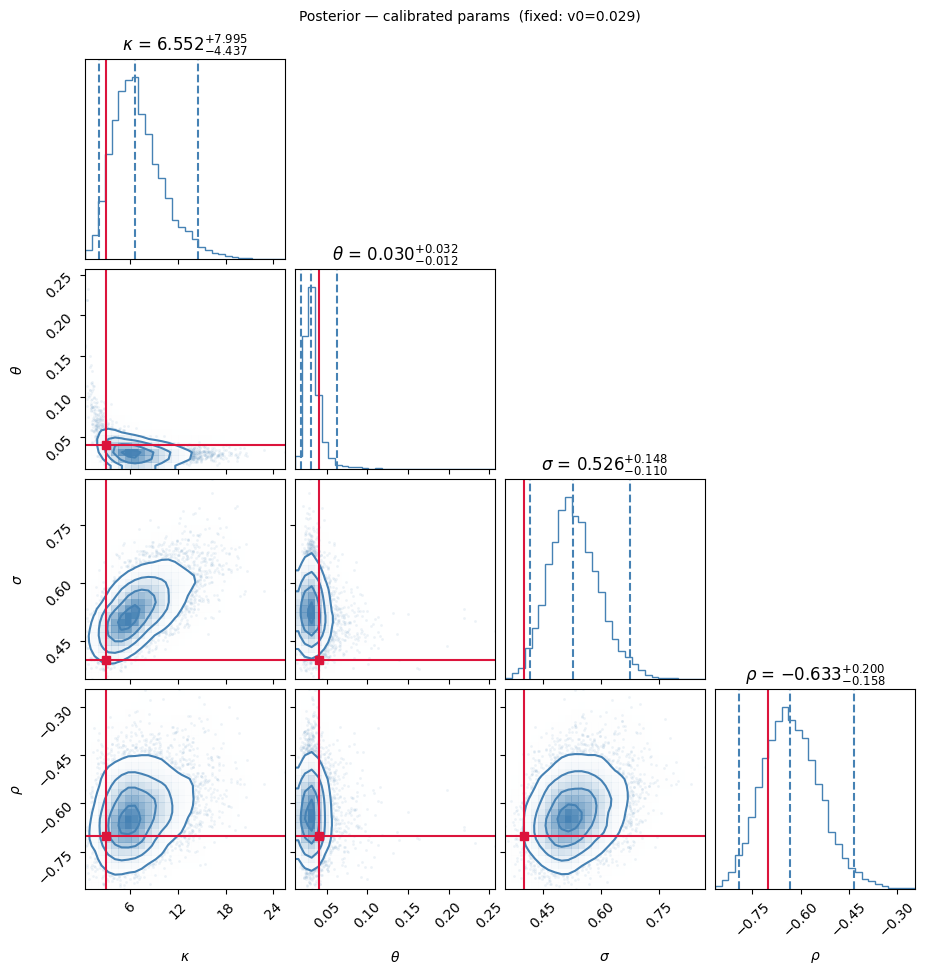

In [9]:
# ── Corner plot over free parameters ─────────────────────────────────────────

labels_map = {"kappa": r"$\kappa$", "theta": r"$\theta$",
              "sigma": r"$\sigma$", "rho": r"$\rho$", "v0": r"$v_0$"}

free_labels  = [labels_map[p] for p in ALL_PARAMS if p not in resolved_fixed]
free_samples = np.column_stack([post[p] for p in ALL_PARAMS if p not in resolved_fixed])
true_free    = ([TRUE_PARAMS[p] for p in ALL_PARAMS if p not in resolved_fixed]
                if USE_SYNTHETIC else None)

fig = corner.corner(
    free_samples, labels=free_labels, truths=true_free, truth_color="crimson",
    color="steelblue", bins=30, smooth=1.0,
    show_titles=True, title_fmt=".3f", quantiles=[0.025, 0.5, 0.975],
)
fig.suptitle(
    f"Posterior — calibrated params  "
    f"({'fixed: ' + ', '.join(f'{p}={resolved_fixed[p]:.3f}' for p in resolved_fixed)})",
    y=1.01, fontsize=10
)
plt.show()

## Diagnostics

These diagnostics work on **both synthetic and real data** — no ground truth required.

| Diagnostic | What it checks | Red flag |
|---|---|---|
| **R-hat / ESS** | Chain convergence | R-hat > 1.01 or ESS% < 20% |
| **Innovation whiteness** | UKF model fit | Serial correlation in normalised innovations |
| **κ·θ sanity** | Mean-reversion force plausibility | κ·θ > 0.5 or < 0.005 for equity |
| **Posterior predictive** | Simulated paths match observed data | Quantile mismatch or autocorrelation mismatch |

In [10]:
# ── Convergence diagnostics ───────────────────────────────────────────────────

print("CONVERGENCE DIAGNOSTICS")
print("─" * 50)
any_warn = False
for p in free_in_idata:
    ess  = float(summary.loc[p, "ess_bulk"])
    rhat = float(summary.loc[p, "r_hat"])
    warn = []
    if rhat > 1.01: warn.append(f"R-hat={rhat:.3f} > 1.01")
    if ess/n_total < 0.20: warn.append(f"ESS={ess/n_total:.1%} < 20%")
    flag = "  ⚠  " + "; ".join(warn) if warn else "  ok"
    print(f"  {p:<8}  R-hat={rhat:.4f}  ESS={ess/n_total:.1%}{flag}")
    if warn: any_warn = True

if any_warn:
    print("\nWarnings detected — consider:")
    print("  • Increasing num_warmup (try 1200 with dense_mass=True)")
    print("  • Checking for multimodality in trace plots")
    print("  • Fixing additional parameters to reduce posterior complexity")
else:
    print("\nAll chains converged cleanly.")

# κ·θ sanity
kt = post["kappa"] * post["theta"]
print(f"\nκ·θ posterior:  mean={kt.mean():.4f}  "
      f"95% CI [{np.percentile(kt,2.5):.4f}, {np.percentile(kt,97.5):.4f}]")
if USE_SYNTHETIC:
    print(f"κ·θ true:       {TRUE_PARAMS['kappa']*TRUE_PARAMS['theta']:.4f}")
if kt.mean() > 0.5:
    print("WARNING: κ·θ > 0.5 — implies annualised long-run vol > 70%; check data units.")
if kt.mean() < 0.005:
    print("WARNING: κ·θ < 0.005 — very low long-run variance; check data units.")

# Feller condition across posterior
feller_satisfied = (2 * post["kappa"] * post["theta"]) > post["sigma"]**2
print(f"\nFeller (2κθ > σ²) satisfied in {feller_satisfied.mean():.1%} of posterior draws")
if feller_satisfied.mean() < 0.9:
    print("WARNING: Feller condition frequently violated — variance can hit zero.")
    print("Consider fixing σ to a lower value or tightening the σ prior.")

CONVERGENCE DIAGNOSTICS
──────────────────────────────────────────────────
  kappa     R-hat=1.0000  ESS=40.8%  ok
  theta     R-hat=1.0010  ESS=44.5%  ok
  sigma     R-hat=1.0000  ESS=68.3%  ok
  rho       R-hat=1.0010  ESS=66.6%  ok

All chains converged cleanly.

κ·θ posterior:  mean=0.2138  95% CI [0.0902, 0.4511]
κ·θ true:       0.1200

Feller (2κθ > σ²) satisfied in 88.1% of posterior draws
Consider fixing σ to a lower value or tightening the σ prior.


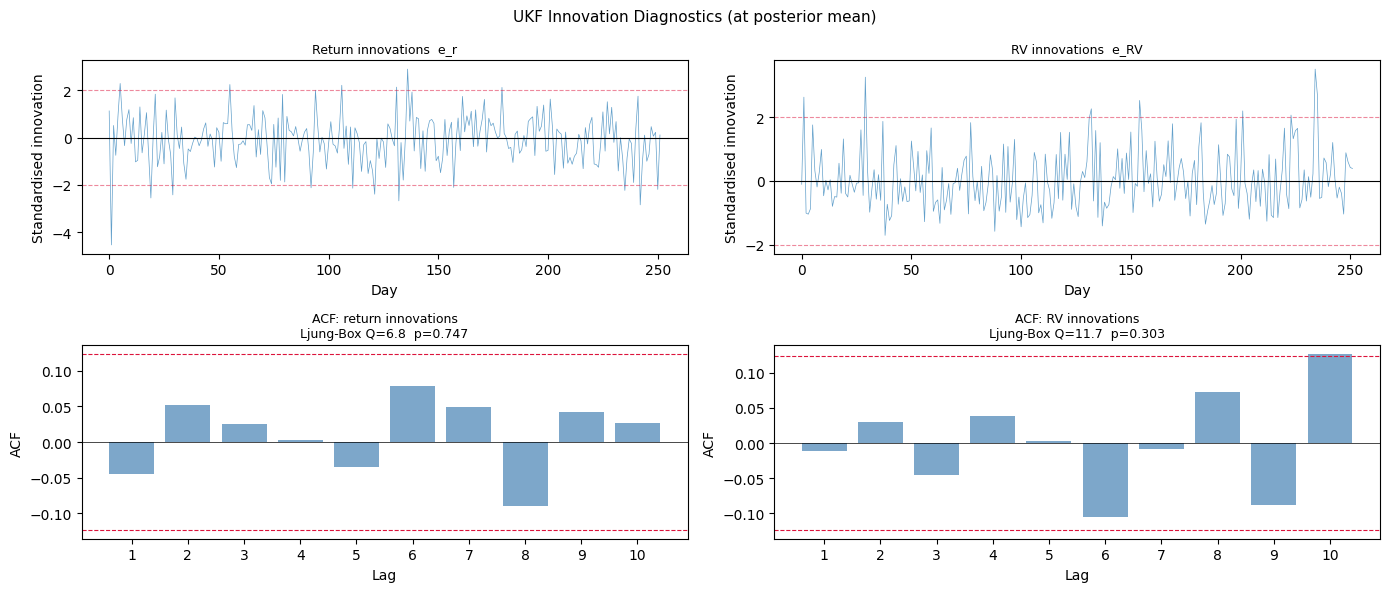

Return innovations:   mean=-0.096  std=1.041  Ljung-Box p=0.747  ✓
RV innovations:       mean=0.042  std=0.938  Ljung-Box p=0.303  ✓



In [11]:
# ── UKF innovation whiteness test ────────────────────────────────────────────
# Run UKF at the posterior mean and inspect the standardised innovations.
# If the innovations are white noise the model is well-specified.
# Serial correlation → model misspecification or UKF mis-tuning.

post_mean = {p: float(post[p].mean()) for p in ALL_PARAMS}
_, fv_pm, ir_std_pm, irv_std_pm = ukf_rv_loglik_jax(
    rdaily_jax, rv_jax, **{k: float(v) for k, v in post_mean.items()})

ir_std  = np.array(ir_std_pm)
irv_std = np.array(irv_std_pm)

# Ljung-Box test for serial correlation (lags 1–10)
from scipy.stats import chi2
def ljung_box(x, lags=10):
    n = len(x)
    acf = [np.corrcoef(x[:-k], x[k:])[0,1] for k in range(1, lags+1)]
    Q = n*(n+2) * sum(a**2/(n-k) for k, a in enumerate(acf, 1))
    p = 1 - chi2.cdf(Q, df=lags)
    return Q, p, acf

Q_r,  p_r,  acf_r  = ljung_box(ir_std)
Q_rv, p_rv, acf_rv = ljung_box(irv_std)

fig, axes = plt.subplots(2, 2, figsize=(14, 6))
fig.suptitle("UKF Innovation Diagnostics (at posterior mean)", fontsize=11)

for ax, data, title in [
    (axes[0,0], ir_std,  "Return innovations  e_r"),
    (axes[0,1], irv_std, "RV innovations  e_RV"),
]:
    ax.plot(data, lw=0.5, alpha=0.7)
    ax.axhline(0, color='k', lw=0.8)
    ax.axhline( 2, color='crimson', lw=0.8, ls='--', alpha=0.5)
    ax.axhline(-2, color='crimson', lw=0.8, ls='--', alpha=0.5)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Day")
    ax.set_ylabel("Standardised innovation")

lags = range(1, 11)
for ax, acf, Q, p, title in [
    (axes[1,0], acf_r,  Q_r,  p_r,  "ACF: return innovations"),
    (axes[1,1], acf_rv, Q_rv, p_rv, "ACF: RV innovations"),
]:
    ax.bar(list(lags), acf, color='steelblue', alpha=0.7)
    ci = 1.96 / np.sqrt(T)
    ax.axhline( ci, color='crimson', ls='--', lw=0.8)
    ax.axhline(-ci, color='crimson', ls='--', lw=0.8)
    ax.axhline(0,   color='k',       lw=0.5)
    ax.set_title(f"{title}\nLjung-Box Q={Q:.1f}  p={p:.3f}", fontsize=9)
    ax.set_xlabel("Lag")
    ax.set_ylabel("ACF")
    ax.set_xticks(list(lags))

plt.tight_layout()
plt.show()

print(f"Return innovations:   mean={ir_std.mean():.3f}  std={ir_std.std():.3f}  "
      f"Ljung-Box p={p_r:.3f}" + ("  ✓" if p_r > 0.05 else "  ⚠ serial correlation"))
print(f"RV innovations:       mean={irv_std.mean():.3f}  std={irv_std.std():.3f}  "
      f"Ljung-Box p={p_rv:.3f}" + ("  ✓" if p_rv > 0.05 else "  ⚠ serial correlation"))
print()
if p_r < 0.05 or p_rv < 0.05:
    print("Serial correlation detected in innovations. Possible causes:")
    print("  • Model misspecification (e.g. jumps, regime switches not captured)")
    print("  • UKF process noise Q underspecified — try increasing sigma prior mean")
    print("  • RV channel noise R_rv underspecified — try reducing H_PER_DAY")

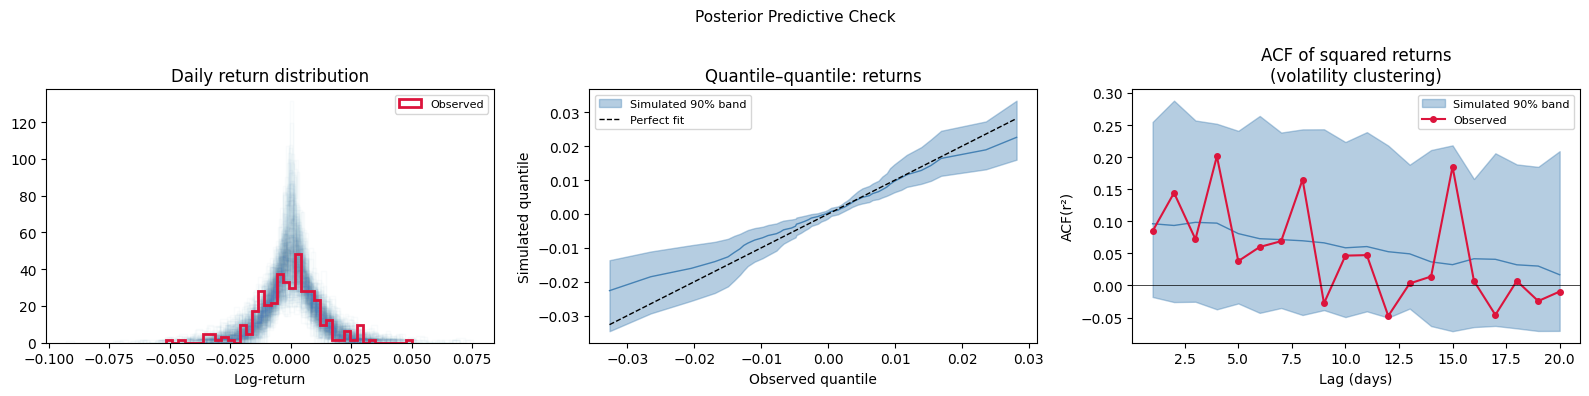

Interpretation:
  QQ plot: points on the diagonal → model captures the return distribution.
  ACF r²:  observed line inside the simulated band → model captures vol clustering.
  If observed ACF is above the band → more volatility persistence than Heston allows
           (consider rough volatility or regime-switching extension).


In [12]:
# ── Posterior predictive check ────────────────────────────────────────────────
# Draw N_SIM parameter sets from the posterior and simulate forward.
# Compare the distribution of simulated daily returns and RV to observed.

N_SIM = 200
rng_ppc = np.random.default_rng(99)

sim_idx = rng_ppc.choice(n_total, size=N_SIM, replace=False)

def simulate_heston_np(kappa, theta, sigma, rho, v0, T=T, mu=MU, dt=dt, rng=None):
    if rng is None: rng = np.random.default_rng()
    v, r = np.zeros(T), np.zeros(T)
    v_cur = float(v0)
    for t in range(T):
        sv    = np.sqrt(max(v_cur, 0.0))
        z1, z2 = rng.standard_normal(), rng.standard_normal()
        dWs   = np.sqrt(dt) * z1
        dWv   = np.sqrt(dt) * (rho*z1 + np.sqrt(max(1-rho**2,0))*z2)
        v_new = max(v_cur + kappa*(theta-v_cur)*dt + sigma*sv*dWv, 0.0)
        r[t]  = (mu - 0.5*v_cur)*dt + sv*dWs
        v_cur = v_new
    return r

sim_returns = np.zeros((N_SIM, T))
for i, idx in enumerate(sim_idx):
    p_draw = {p: float(post[p][idx]) for p in ALL_PARAMS}
    sim_returns[i] = simulate_heston_np(**p_draw, rng=rng_ppc)

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Posterior Predictive Check", fontsize=11)

# 1. Return distribution
ax = axes[0]
for i in range(N_SIM):
    ax.hist(sim_returns[i], bins=40, density=True, histtype='step',
            color='steelblue', alpha=0.03)
ax.hist(r_daily, bins=40, density=True, histtype='step',
        color='crimson', lw=2, label='Observed')
ax.set_title("Daily return distribution")
ax.set_xlabel("Log-return")
ax.legend(fontsize=8)

# 2. Quantile–quantile of returns
ax = axes[1]
obs_q = np.quantile(r_daily, np.linspace(0.02, 0.98, 50))
sim_q_all = np.array([np.quantile(sim_returns[i], np.linspace(0.02, 0.98, 50))
                       for i in range(N_SIM)])
ax.fill_between(obs_q, np.percentile(sim_q_all, 5, axis=0),
                        np.percentile(sim_q_all, 95, axis=0),
                color='steelblue', alpha=0.4, label='Simulated 90% band')
ax.plot(obs_q, np.median(sim_q_all, axis=0), color='steelblue', lw=1)
ax.plot(obs_q, obs_q, 'k--', lw=1, label='Perfect fit')
ax.set_title("Quantile–quantile: returns")
ax.set_xlabel("Observed quantile")
ax.set_ylabel("Simulated quantile")
ax.legend(fontsize=8)

# 3. Autocorrelation of squared returns (volatility clustering)
ax = axes[2]
max_lag = 20
obs_acf = [np.corrcoef(r_daily[:-k]**2, r_daily[k:]**2)[0,1] for k in range(1, max_lag+1)]
sim_acf_all = np.array([
    [np.corrcoef(sim_returns[i][:-k]**2, sim_returns[i][k:]**2)[0,1]
     for k in range(1, max_lag+1)]
    for i in range(N_SIM)])
lags = range(1, max_lag+1)
ax.fill_between(list(lags), np.percentile(sim_acf_all, 5, axis=0),
                             np.percentile(sim_acf_all, 95, axis=0),
                color='steelblue', alpha=0.4, label='Simulated 90% band')
ax.plot(list(lags), np.median(sim_acf_all, axis=0), color='steelblue', lw=1)
ax.plot(list(lags), obs_acf, 'o-', color='crimson', ms=4, lw=1.5, label='Observed')
ax.axhline(0, color='k', lw=0.5)
ax.set_title("ACF of squared returns\n(volatility clustering)")
ax.set_xlabel("Lag (days)")
ax.set_ylabel("ACF(r²)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Interpretation:")
print("  QQ plot: points on the diagonal → model captures the return distribution.")
print("  ACF r²:  observed line inside the simulated band → model captures vol clustering.")
print("  If observed ACF is above the band → more volatility persistence than Heston allows")
print("           (consider rough volatility or regime-switching extension).")

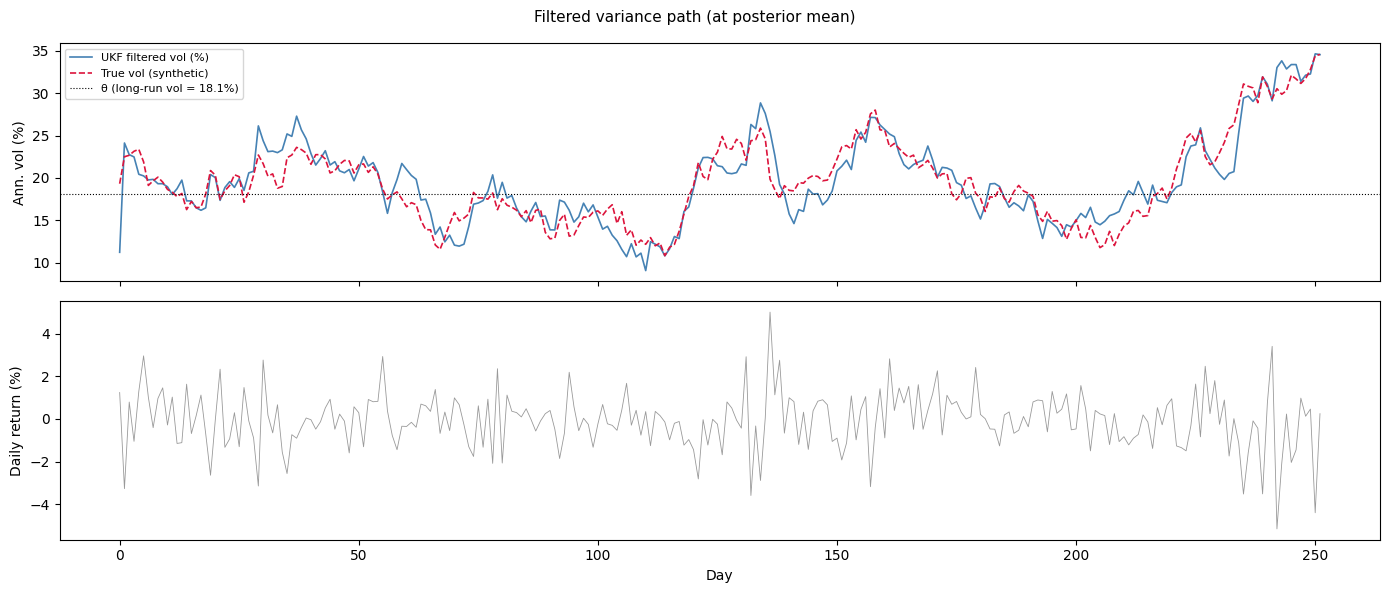

Posterior mean parameters:
  kappa    = 7.0251  (true: 3.0000)
  theta    = 0.0329  (true: 0.0400)
  sigma    = 0.5311  (true: 0.4000)
  rho      = -0.6272  (true: -0.7000)
  v0       = 0.0294 [FIXED]  (true: 0.0400)

Implied long-run vol: 18.1%  (ann.)
Vol-of-vol:           0.531
Mean reversion τ:     0.1 years  (1/κ)


In [13]:
# ── Filtered variance path ────────────────────────────────────────────────────
# Shows the UKF's estimate of v_t at the posterior mean.
# On real data this is your latent volatility estimate — no ground truth needed.
#
# NOTE: v_t in the Heston model is already the *annualised* variance.
# Annualised vol = sqrt(v_t), not sqrt(v_t * 252).

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
fig.suptitle("Filtered variance path (at posterior mean)", fontsize=11)

days = np.arange(T)
ann_vol = np.sqrt(np.array(fv_pm)) * 100   # v_t is annualised variance → vol = sqrt(v_t)

ax = axes[0]
ax.plot(days, ann_vol, color='steelblue', lw=1.2, label='UKF filtered vol (%)')
if USE_SYNTHETIC and v_true is not None:
    ax.plot(days, np.sqrt(v_true) * 100, color='crimson', lw=1.2,
            ls='--', label='True vol (synthetic)')
ax.axhline(np.sqrt(post_mean['theta']) * 100, color='k', lw=0.8, ls=':',
           label=f'θ (long-run vol = {np.sqrt(post_mean["theta"])*100:.1f}%)')
ax.set_ylabel("Ann. vol (%)")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(days, r_daily * 100, color='grey', lw=0.6, alpha=0.8)
ax.set_ylabel("Daily return (%)")
ax.set_xlabel("Day")

plt.tight_layout()
plt.show()

print(f"Posterior mean parameters:")
for p in ALL_PARAMS:
    tag = " [FIXED]" if p in resolved_fixed else ""
    tv  = f"  (true: {TRUE_PARAMS[p]:.4f})" if USE_SYNTHETIC else ""
    print(f"  {p:<8} = {post_mean[p]:.4f}{tag}{tv}")
print(f"\nImplied long-run vol: {np.sqrt(post_mean['theta'])*100:.1f}%  (ann.)")
print(f"Vol-of-vol:           {post_mean['sigma']:.3f}")
print(f"Mean reversion τ:     {1/post_mean['kappa']:.1f} years  (1/κ)")

## What the research tells us about running this in production

The experiments in `heston-ukf-nuts.ipynb` establish several hard constraints on
what historical calibration can and cannot deliver. These directly shape how to
interpret and trust the output of this notebook.

### You must have realized variance — returns alone are not usable

On daily returns only, the posterior for ρ has the wrong sign and κ collapses toward
zero regardless of how much data you use. These are not wide estimates — they are
actively incorrect. If your data pipeline cannot produce an intraday RV series
(sum of squared intraday returns), do not run this calibration. A result will be
produced but it will be misleading.

Minimum viable data: daily log-returns + daily RV from at least H=8 intraday bars.
Better: H=13 (30-min) or H=78 (5-min), which tightens the σ estimate significantly.

### More history is not better without RV

Five years of daily returns produced worse results than one year, taking 70× longer
to run and with R-hat of 1.5. Longer windows without the RV channel sharpen the
κ–θ banana without resolving it, and NUTS exhausts its tree depth. If you extend
to multi-year windows, keep the RV channel and watch for structural breaks
(split the window in halves and compare posterior means of θ and κ).

### What this calibration reliably delivers

| Output | Reliability | Use for |
|---|---|---|
| **ρ** (leverage) | High — recovered to within 0.01 of truth | Direction of vol-return correlation; skew intuition |
| **θ** (long-run variance) | Good — in CI, but posterior mean biased low | Long-run vol regime; anchoring simulations |
| **κ** (mean-reversion speed) | Moderate — in CI but wide; half-life is meaningful | Vol persistence; risk horizon for stress scenarios |
| **σ** (vol-of-vol) | Low — outside CI, biased high | Treat as upper bound; cross-check with options arm |
| **v₀** (initial variance) | Fixed to data — not estimated | Starting point for forward simulation only |

### How to use alongside the options calibration

The options arm pins down σ precisely from the curvature of the implied vol smile.
The recommended workflow is:
1. Run the options calibration to get a point estimate of σ (and ρ as a cross-check)
2. Set `FIXED["sigma"]` in the config cell to that value
3. Run this notebook with σ fixed — the remaining 3-parameter posterior (κ, θ, ρ)
   is well-identified from returns + RV and converges cleanly
4. Compare ρ between the two arms as a consistency check: large disagreement
   signals either a data problem or a regime the Heston model cannot capture

### The Feller condition as a production health check

When `FELLER_STRENGTH = 0` (unconstrained), the Feller condition `2κθ > σ²` is
violated in over 90% of posterior draws on the default setup. This means the model
implies variance can hit zero — not a valid Heston process. The Feller diagnostic
in the convergence cell is a quick health check: if satisfaction drops below ~80%
with the penalty active, it signals either a data issue (σ is being pushed too high
by noisy RV) or a genuine model-data mismatch worth investigating.
